# 1. Project overview

The general goal of this project is to build a machine learning model that predicts how much money clients will spend for subscription and purchases on the platform.

The goal of this project is to predict monthly customer spend based on available customer features and to compare the performance of various regression models. The problem is formulated as a regression task because the target variable `monthly_spend_pln` is continuous.

The project covers the complete machine learning workflow, including:
- train/test splitting
- preprocessing
- cross-validation
- model comparison
- hyperparameter optimization
- final model evaluation
- residual analysis and error analysis
- conclusions

The data for this project was generated by an LLM and intentionally included dirty data.

# 2. Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_validate, train_test_split, KFold, GridSearchCV, cross_val_score, RepeatedKFold
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor
import optuna

import joblib
import os

# 3. Load Data and Duplicates

The dataset contains 10,000 observations describing customer demographics, behaviour, account characteristics and churn status. During the initial data inspection, 60 duplicated records associated with 30 duplicated customers were identified. Records with the same `customer_id` contain different demographic or account-related values.

For the purpose of this project, it is assumed that duplicate customer_id results from a system error. Given the drastic differences in demographic features across these duplicate records, each instance is treated as representing a distinct customer. For this reason, the duplicated customer records were retained. Removing them automatically could result in the loss of potentially valuable information and reduce the amount of data available for model training.

In [2]:
data = pd.read_csv("../data/subscription_customers_dirty.csv")

data.head()

,customer_id,age,city,plan,acquisition_channel,join_date,monthly_income_pln,tenure_months,avg_logins_last_30d,support_tickets_last_30d,satisfaction_score,auto_renew,discount_pct,monthly_spend_pln,churned
0,C000001,32,Poznań,Basic,referral,2022-05-21,7500.94,37,15,1,9.0,1,5,149.74,0
1,C000002,38,Łódź,Standard,paid_search,2024-11-26,5549.57,7,0,0,6.0,1,0,94.50,0
2,C000003,39,Warszawa,Basic,referral,2023-05-25,13992.16,25,9,3,6.0,1,0,127.67,0
3,C000004,39,Warszawa,Standard,organic,2022-09-29,8370.21,33,8,0,7.0,1,15,175.89,0
4,C000005,38,Gdańsk,Premium,referral,2025-06-07,9492.17,1,14,0,7.0,1,0,167.46,1


In [3]:
dup_cols = ['customer_id', 'age', 'city', 'plan', 'acquisition_channel', 'join_date']
duplicates = data[data.duplicated(subset=['customer_id'], 
                                  keep=False)].sort_values(by='customer_id')[dup_cols]

print(duplicates)

     customer_id  age      city      plan acquisition_channel   join_date
60       C000061   48   Wrocław  Standard         paid_search  2022-03-05
7447     C000061   26    Kraków   Premium             organic  2025-03-07
5727     C000494   39  Katowice  Standard             organic  2024-01-06
493      C000494   24    Lublin  Standard         paid_search  2024-10-31
884      C000885   41    Lublin     Basic             partner  2024-07-06
3095     C000885   34   Wrocław   Premium         paid_search  2024-10-21
5061     C001389   46  Katowice     Basic         paid_search  2025-06-06
1388     C001389   54    Poznań   Premium            referral  2022-07-17
1528     C001529   42   Wrocław  Standard             organic  2023-07-20
7651     C001529   19      Łódź  Standard             organic  2025-03-18
1942     C001943   31   Wrocław  Standard         paid_search  2022-09-14
1310     C001943   31    Gdańsk  Standard         paid_search  2024-05-12
8056     C002540   36    Gdańsk    Bas

# 4. Data quality & cleaning 

Instead of removing entire rows with data errors, they were replaced with `NaN` values.

* `age`: Replaced values $< 18$ or $\ge 99$ with `NaN` to handle outliers and out-of-scope entries.
* `monthly_spend_pln`: Replaced negative values with `NaN`. Rows with missing values in this target variable were dropped followed by an index reset.
* `monthly_spend_pln`: There are only five values above 300 PLN and in all five cases they are 2,500. Therefore, they are considered data errors and replaced with `NaN` values.
* `monthly_income_pln`: Replaced negative values and known sentinel missing code values (`999999`) with `NaN`.

In [4]:
data[data['monthly_spend_pln'] >= 300]

,customer_id,age,city,plan,acquisition_channel,join_date,monthly_income_pln,tenure_months,avg_logins_last_30d,support_tickets_last_30d,satisfaction_score,auto_renew,discount_pct,monthly_spend_pln,churned
2389,C002390,47,Wrocław,Standard,social,2024-08-11,10716.70,10,6,1,9.0,0,10,2500.0,0
2934,C002935,36,Lublin,Basic,organic,2024-06-16,2840.60,12,16,0,6.0,0,20,2500.0,1
3273,C003274,42,Łódź,Basic,paid_search,2022-06-05,14278.43,37,11,2,7.0,1,10,2500.0,0
3372,C003373,19,Lublin,Standard,paid_search,2023-02-21,10223.06,28,6,0,8.0,1,0,2500.0,0
9701,C009702,33,Kraków,Standard,organic,2024-08-05,7617.57,11,9,1,NaN,0,20,2500.0,0


In [5]:
data.drop(columns=['customer_id', 'join_date'], inplace=True)

categorical_cols = ['city', 'plan', 'acquisition_channel']
for col in categorical_cols:
    data[col] = data[col].str.strip().str.lower()

data.loc[
    (data['age'] >= 99) |
    (data['age'] < 18),
    'age'
] = np.nan

data.loc[(data['monthly_spend_pln'] < 0) | (data['monthly_spend_pln'] >= 300), 'monthly_spend_pln'] = np.nan

data.loc[
    (data['monthly_income_pln'] < 0) |
    (data['monthly_income_pln'] == 999999),
    'monthly_income_pln'
] = np.nan

data = data.dropna(subset=["monthly_spend_pln"]).reset_index(drop=True)

print("Missing values after cleaning:")
display(data.isna().sum().sort_values(ascending=False))

Missing values after cleaning:


monthly_income_pln          157
satisfaction_score          129
city                        109
age                           8
plan                          0
acquisition_channel           0
tenure_months                 0
avg_logins_last_30d           0
support_tickets_last_30d      0
auto_renew                    0
discount_pct                  0
monthly_spend_pln             0
churned                       0
dtype: int64

# 5. Exploratory data analysis

* `data.info()` shows a general overview of the dataset. The dataset contains $9992$ rows and $13$ columns. It includes both numerical and categorical variables. Some columns contain missing values. The missing values appear in `age`, `city`, `monthly_income_pln`, and `satisfaction_score`. The other columns have complete data.

* `data.describe()` presents average customer is about $35$ years old and has been with the company for around $21$ months. The average monthly income is approximately $8,663 PLN$, while the average monthly spend is about $140$ PLN. Most customers log in around $11$ times during the last 30 days. The average satisfaction score is about $7.8$ out of $10$. Most customers also have auto-renew enabled.
The `monthly_spend_pln` variable has a range from $0$ to $275 PLN$. 

* Based on the heat map `tenure_months` and `avg_logins_last_30d` have the strongest correlation with `monthly_spend_pln`; plan, which is categorical and not included in this matrix, turns out to have an even larger effect (see section 17).

* Monthly spend differs clearly across subscription plans. Premium customers have the highest average monthly spend (182.25 PLN), followed by Standard (141.45 PLN) and Basic (114.11 PLN). The distributions also show some variation within each plan, with Premium having the highest spending levels overall.


In [6]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9992 entries, 0 to 9991
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       9984 non-null   float64
 1   city                      9883 non-null   object 
 2   plan                      9992 non-null   object 
 3   acquisition_channel       9992 non-null   object 
 4   monthly_income_pln        9835 non-null   float64
 5   tenure_months             9992 non-null   int64  
 6   avg_logins_last_30d       9992 non-null   int64  
 7   support_tickets_last_30d  9992 non-null   int64  
 8   satisfaction_score        9863 non-null   float64
 9   auto_renew                9992 non-null   int64  
 10  discount_pct              9992 non-null   int64  
 11  monthly_spend_pln         9992 non-null   float64
 12  churned                   9992 non-null   int64  
dtypes: float64(4), int64(6), object(3)
memory usage: 1014.9+ KB


,age,monthly_income_pln,tenure_months,avg_logins_last_30d,support_tickets_last_30d,satisfaction_score,auto_renew,discount_pct,monthly_spend_pln,churned
count,9984.000000,9835.000000,9992.000000,9992.000000,9992.000000,9863.000000,9992.000000,9992.000000,9992.000000,9992.000000
mean,35.217047,8662.802826,20.793735,10.688851,0.666433,7.807259,0.768915,7.189752,138.804485,0.192654
std,9.652682,3985.280487,12.238079,4.431663,1.055426,1.271045,0.421548,7.458813,40.273104,0.394403
min,18.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,5832.340000,10.000000,8.000000,0.000000,7.000000,1.000000,0.000000,109.475000,0.000000
50%,35.000000,7824.220000,21.000000,11.000000,0.000000,8.000000,1.000000,5.000000,138.465000,0.000000
75%,42.000000,10598.490000,31.000000,14.000000,1.000000,9.000000,1.000000,15.000000,166.152500,0.000000
max,71.000000,35000.000000,42.000000,29.000000,12.000000,10.000000,1.000000,20.000000,275.150000,1.000000


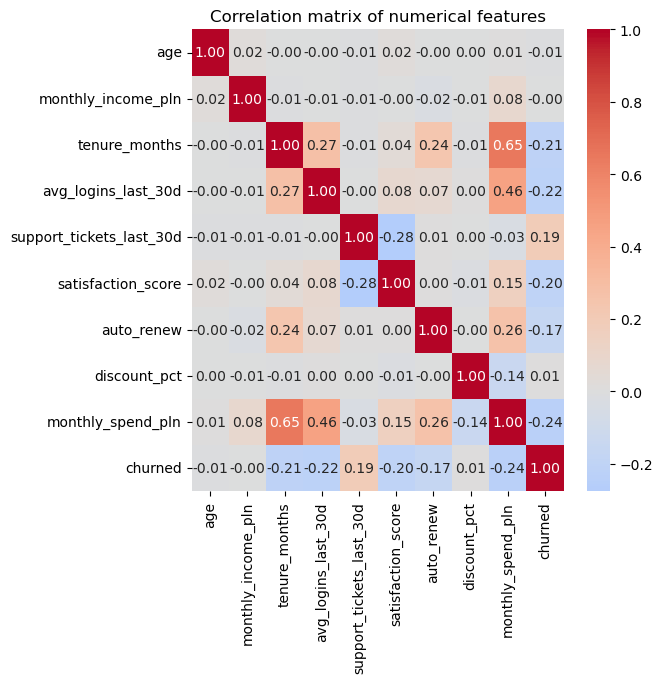

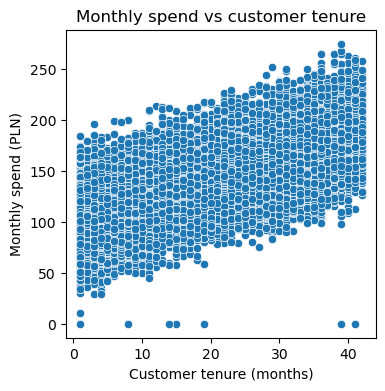

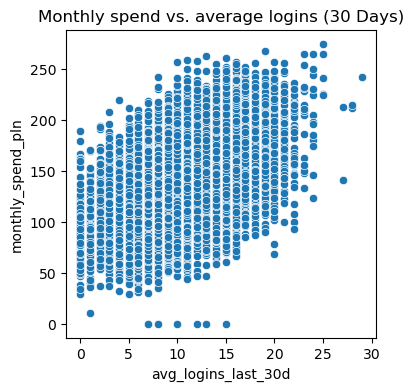

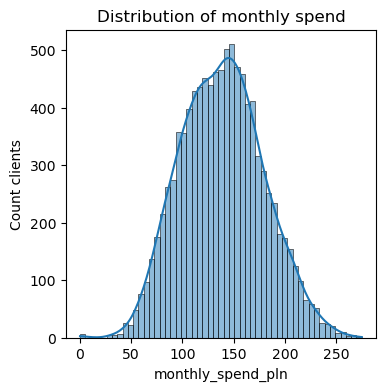

In [7]:
plt.figure(figsize=(6, 6))
sns.heatmap(data.select_dtypes("number").corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f") 
plt.title('Correlation matrix of numerical features')
plt.show()

plt.figure(figsize=(4, 4))
sns.scatterplot(data, x="tenure_months", y="monthly_spend_pln")
plt.title('Monthly spend vs customer tenure')
plt.xlabel("Customer tenure (months)")
plt.ylabel("Monthly spend (PLN)")
plt.show()

plt.figure(figsize=(4, 4))
sns.scatterplot(data, x="avg_logins_last_30d", y="monthly_spend_pln")
plt.title('Monthly spend vs. average logins (30 Days)')
plt.show()

plt.figure(figsize=(4, 4))
sns.histplot(data["monthly_spend_pln"], kde=True)
plt.ylabel('Count clients')
plt.title('Distribution of monthly spend')
plt.show()

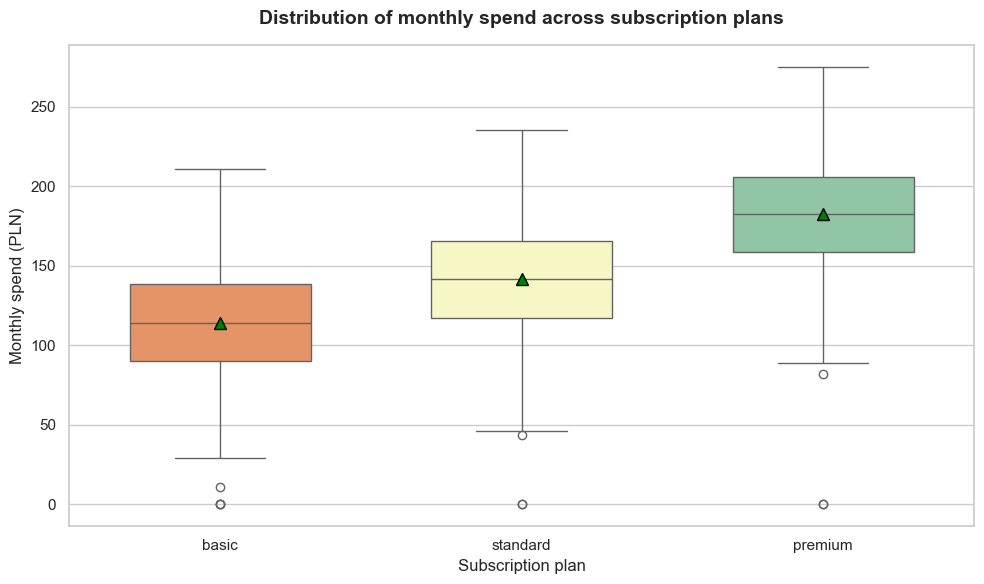

--- DESCRIPTIVE STATISTICS OF MONTHLY SPEND BY PLAN ---
           count        mean        std  min       25%     50%       75%  \
plan                                                                       
basic     3801.0  114.112484  31.981031  0.0   89.9800  113.78  138.7100   
premium   1899.0  182.246609  32.426921  0.0  158.6350  182.63  205.9750   
standard  4292.0  141.450734  31.988964  0.0  117.3475  141.94  165.3225   

             max  
plan              
basic     210.81  
premium   275.15  
standard  235.32  


In [8]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="plan",
    y="monthly_spend_pln",
    hue="plan",  
    legend=False,  
    palette="Spectral",
    width=0.6,
    showmeans=True,  
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "black",
        "markersize": 8,
    },
)

plt.title(
    "Distribution of monthly spend across subscription plans",
    fontsize=14,
    pad=15,
    fontweight="bold",
)
plt.xlabel("Subscription plan", fontsize=12)
plt.ylabel("Monthly spend (PLN)", fontsize=12)

plt.tight_layout()
plt.show()

print("--- DESCRIPTIVE STATISTICS OF MONTHLY SPEND BY PLAN ---")
stats = data.groupby("plan")["monthly_spend_pln"].describe()
print(stats)


# 6. Target definition

In this step, the features are separated from the target variable. The target variable is `monthly_spend_pln` so it is removed from input features. Churned was also excluded because it represents an outcome that may occur after or be directly related to the prediction period. Including it could introduce target leakage depending on when the feature is observed

In [9]:
X = data.drop(columns=["monthly_spend_pln", "churned"])
y = data["monthly_spend_pln"]

# 7. Train/test split

This cell splits the dataset into training and testing sets to evaluate model performance fairly. We allocate 80% of the data for training the models and reserve 20% for testing their predictions on unseen data. The `random_state=42` parameter is used to fix the random seed, ensuring that the split is reproducible every time the notebook runs.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8. Preprocessing pipeline

For numerical features, missing values are replaced with the median and the values are standardized.
For categorical features, missing values are replaced with the most frequent value. Then, categorical variables are converted into numerical values using one-hot encoding.

All preprocessing steps are placed inside a scikit-learn pipeline. This makes sure that the preprocessing is fitted only on the training data and to avoid data leackage.

In [11]:
numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),
                                    ('scaler', StandardScaler())])
categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
numeric_selector = make_column_selector(dtype_include="number")
categorical_selector = make_column_selector(dtype_include="object")

preprocessor = ColumnTransformer([('num', numeric_transformer, numeric_selector),
                                 ('cat', categorical_transformer, categorical_selector)])

In [12]:
pipelines = { 
    "Dummy (median)": Pipeline([('preprocessor', preprocessor), ('regressor', DummyRegressor(strategy='median'))]),
    "Linear Regression": Pipeline([('preprocessor', preprocessor), ('regressor', LinearRegression())]), 
    "Ridge": Pipeline([('preprocessor', preprocessor), ('regressor', Ridge(alpha=1.0))]), 
    "Lasso": Pipeline([('preprocessor', preprocessor), ('regressor', Lasso(alpha=1.0))]), 
    "Elastic Net": Pipeline([('preprocessor', preprocessor), ('regressor', ElasticNet(alpha=1.0))]), 
    "Decision Tree": Pipeline([('preprocessor', preprocessor), ('regressor', DecisionTreeRegressor(random_state=42))]),
    "XGB": Pipeline([('preprocessor', preprocessor), ('regressor', XGBRegressor(random_state=42))])
}

# 9. Cross validation

5-fold cross-validation used to compare the regression models more reliably. The training data is divided into five parts. The model is trained on four parts and tested on the remaining part. This process is repeated five times.

Ridge and Linear Regression achieved almost identical performance, with the lowest CV MAE of approximately 11.36 PLN and CV R² of 0.87. Lasso performed slightly worse, while XGBoost did not outperform the linear models. These results suggest that a relatively simple linear relationship captures the main patterns in monthly spending effectively.

Repeated cross-validation confirmed the results with low variability in MAE and R² across repeated folds.

Model selection was based primarily on MAE because it directly reflects the typical prediction error in PLN. RMSE and R² were reported as complementary metrics.

To double-check our baseline performance, a simple model that always predicts the median monthly spend gets a CV MAE of 32.40 PLN. Every real model performs much better than this, which proves that our features contain useful information.

In [13]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "r2": "r2"
}

cv_results = []

for name, model in pipelines.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    fold_rmse = np.sqrt(-scores["test_mse"])

    cv_results.append({
        "Model": name,
        "CV MAE": -scores["test_mae"].mean(),
        "CV RMSE": fold_rmse.mean(),
        "CV RMSE std": fold_rmse.std(),
        "CV R2": scores["test_r2"].mean()
    })

comparison_cv = (
    pd.DataFrame(cv_results)
    .sort_values("CV MAE")
    .reset_index(drop=True)
)

comparison_cv

,Model,CV MAE,CV RMSE,CV RMSE std,CV R2
0,Ridge,11.363958,14.409319,0.524094,0.870170
1,Linear Regression,11.364117,14.409165,0.524185,0.870173
2,Lasso,11.927697,15.102929,0.592038,0.857345
3,XGB,12.353804,15.627986,0.456354,0.847333
4,Decision Tree,17.257552,21.829153,0.132639,0.702359
5,Elastic Net,18.443954,22.985153,0.469388,0.669941
6,Dummy (median),32.396221,40.020519,0.199742,-0.000271


# 10. Repeated cross-validation

Repeated cross-validation is used to check the stability of the best models. Linear Regression, Ridge, and Lasso achieved the best cross-validation results, so they were selected for repeated cross-validation.
The data is split into 10 folds, and the process is repeated 10 times with different splits. This gives a more reliable estimate of the model's performance.

Repeated cross-validation confirmed the standard CV results. Ridge and Linear Regression performed almost identically, with a mean MAE of 11.36 PLN and mean R² of 0.87. The low standard deviations show that model performance is stable across repeated folds. Lasso performed slightly worse, with a mean MAE of 11.92 PLN.

In [14]:
repeated_cv = RepeatedKFold(
    n_splits=10,
    n_repeats=10,
    random_state=42
)

models_to_validate = {
    "Linear Regression": pipelines["Linear Regression"],
    "Ridge": pipelines["Ridge"],
    "Lasso": pipelines["Lasso"]
}

repeated_results = []

for name, model in models_to_validate.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=repeated_cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=-1,
    )

    repeated_results.append({
        "Model": name,
        "Mean MAE": -scores["test_mae"].mean(),
        "Std MAE": scores["test_mae"].std(),
        "Mean RMSE": -scores["test_rmse"].mean(),
        "Std RMSE": scores["test_rmse"].std(),
        "Mean R2": scores["test_r2"].mean(),
        "Std R2": scores["test_r2"].std(),
    })

repeated_results_df = pd.DataFrame(repeated_results).sort_values(by="Mean MAE", ascending=True)
repeated_results_df

,Model,Mean MAE,Std MAE,Mean RMSE,Std RMSE,Mean R2,Std R2
1,Ridge,11.359525,0.321071,14.390939,0.729795,0.870141,0.013068
0,Linear Regression,11.359789,0.322493,14.391575,0.731589,0.870128,0.013107
2,Lasso,11.919793,0.344395,15.087287,0.720125,0.857333,0.013206


# 11. Hyperparameter optimization with GridSearchCV

Grid Search showed that both Lasso and Ridge achieved very similar performance. Lasso achieved the lowest CV MAE of 11.36 PLN with α = 0.03, while Ridge achieved almost the same with α = 5.4. The difference in MAE was unimportant, indicating that both regularized linear models perform similarly on this dataset. The grid was narrowed over several rounds of search.

In [15]:
ridge_grid = GridSearchCV(
    estimator=pipelines["Ridge"],
    param_grid={"regressor__alpha": [5.3, 5.4, 5.5]
},
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
ridge_grid.fit(X_train, y_train)

lasso_grid = GridSearchCV(
    estimator=pipelines["Lasso"],
    param_grid={"regressor__alpha": [0.02, 0.03, 0.04]},
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
lasso_grid.fit(X_train, y_train)

grid_results = [
    {
        "Model": "Ridge",
        "Best Params": str(ridge_grid.best_params_),
        "Best CV MAE": -ridge_grid.best_score_
    },
    {
        "Model": "Lasso",
        "Best Params": str(lasso_grid.best_params_),
        "Best CV MAE": -lasso_grid.best_score_
    }
]

grid_results_df = pd.DataFrame(grid_results).sort_values("Best CV MAE")
grid_results_df

,Model,Best Params,Best CV MAE
1,Lasso,{'regressor__alpha': 0.03},11.360757
0,Ridge,{'regressor__alpha': 5.4},11.363824


# 12. XGBoost hyperparameter optimization with Optuna

XGB with optuna achieved a CV MAE of 11.37 PLN with a relatively shallow XGBoost model (`max_depth=2`). The optimized model is slightly worse than tuned Lasso and Ridge models. However, the differences in CV MAE are very small. Therefore the final model will be selected based on the cross-validation results, while the test set will be used only for the final evaluation of the selected model.

In [16]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def optuna_tune(trial):
    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 50, 400, step=50
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 2, 5
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.5, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.5, 1.0
        ),
        "gamma": trial.suggest_float(
            "gamma", 1e-8, 1.0, log=True
        ),
        "random_state": 42
    }

    xgb_optuna = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", XGBRegressor(**params))
    ])

    scores = cross_val_score(
        xgb_optuna,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    return -scores.mean()


study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(optuna_tune, n_trials=75)

best_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        **study.best_params,
        random_state=42
    ))
])

print("Best Optuna parameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

print(f"Best CV MAE: {study.best_value:.4f}")

Best Optuna parameters:
n_estimators: 400
max_depth: 2
learning_rate: 0.048257423603899154
subsample: 0.675235915488573
colsample_bytree: 0.5413611871705306
gamma: 5.05795411486616e-07
Best CV MAE: 11.3678


# 13. Final comparison

The four final models achieved very similar cross-validation performance. Lasso achieved the lowest CV MAE at 11.361 PLN, followed by Ridge, Linear Regression and XGB. The differences in the main MAE metric are practically identical, and the error is insignificant. RMSE and R² were also almost identical across all models.

All four models are very similar to each other. However based on the primary evaluation metric, **Linear Model Lasso** is selected as the final model. 

In [17]:
finalists = {
    "Linear Regression": pipelines["Linear Regression"],
    "Ridge GridSearch": ridge_grid.best_estimator_,
    "Lasso GridSearch": lasso_grid.best_estimator_,
    "XGB Optuna": best_xgb
}

final_results = []

for name, model in finalists.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        },
        n_jobs=-1
    )

    final_results.append({
        "Model": name,
        "CV MAE": -scores["test_mae"].mean(),
        "CV RMSE": -scores["test_rmse"].mean(),
        "CV RMSE std": scores["test_rmse"].std(),
        "CV R2": scores["test_r2"].mean()
    })

final_comparison = (
    pd.DataFrame(final_results)
    .sort_values("CV MAE")
    .reset_index(drop=True)
)

final_comparison.sort_values(by="CV MAE")

,Model,CV MAE,CV RMSE,CV RMSE std,CV R2
0,Lasso GridSearch,11.360757,14.407854,0.532853,0.870191
1,Ridge GridSearch,11.363824,14.409372,0.524547,0.870169
2,Linear Regression,11.364117,14.409165,0.524185,0.870173
3,XGB Optuna,11.367830,14.425711,0.549937,0.869857


# 14. Final model evaluation

The optimized Linear Lasso model is trained on the training data and then used to make predictions on the test set.

In [18]:
final_model = lasso_grid.best_estimator_
final_model_name = "Lasso GridSearch"

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

os.makedirs("../models", exist_ok=True)
joblib.dump(final_model, "../models/regression_model.pkl")

['../models/regression_model.pkl']

# 15. Final model diagnostics

The final Linear Lasso model achieved a MAE of 11.43 PLN, an RMSE of 15.38 PLN, and an R² score of 0.86 on the test set.

The table below compares the model's performance during cross-validation with its performance on the test set. The results show similar values for both datasets, indicating consistent model performance.

On the actual vs. predicted plot most data points closely align with the red dashed diagonal line, which visualizes the high R2 score of 0.86 and low overall prediction errors. 

The predictions show consistent performance across most spending levels, supporting the stability observed between cross-validation and the test set. However, a few distinct outliers appear near the 0 PLN actual spend mark, where the model overestimates values up to 210 PLN. Aside from these few edge cases, the visual alignment confirms that the final Lasso model captures the underlying pattern very effectively.

On the residual plot the errors are randomly distributed around the red dashed zero line. It proves the model gives fair results. The prediction errors are steady, which means the model is reliable. Most residuals stay within a tight range of -50 to +50 PLN, which aligns well with the low MAE and RMSE metrics. However, a few significant negative outliers appear between -100 and -210 PLN, representing cases where the model heavily overestimated the actual spend. Overall, the absence of strong patterns in the residuals supports the conclusion that the Lasso model fits the data properly.

In [19]:
final_mae = mean_absolute_error(y_test, y_pred)
final_rmse = mean_squared_error(y_test, y_pred) ** 0.5
final_r2 = r2_score(y_test, y_pred)

print(f"Final model: {final_model_name}")
print(f"Test MAE:  {final_mae:.2f} PLN")
print(f"Test RMSE: {final_rmse:.2f} PLN")
print(f"Test R²:   {final_r2:.3f}")

Final model: Lasso GridSearch
Test MAE:  11.43 PLN
Test RMSE: 15.38 PLN
Test R²:   0.861


In [20]:
final_metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "CV": [
        final_comparison.loc[
            final_comparison["Model"] == "Lasso GridSearch", "CV MAE"
        ].iloc[0],
        final_comparison.loc[
            final_comparison["Model"] == "Lasso GridSearch", "CV RMSE"
        ].iloc[0],
        final_comparison.loc[
            final_comparison["Model"] == "Lasso GridSearch", "CV R2"
        ].iloc[0]
    ],
    "Test": [
        final_mae,
        final_rmse,
        final_r2
    ]
})

final_metrics

,Metric,CV,Test
0,MAE,11.360757,11.431773
1,RMSE,14.407854,15.377000
2,R²,0.870191,0.861112


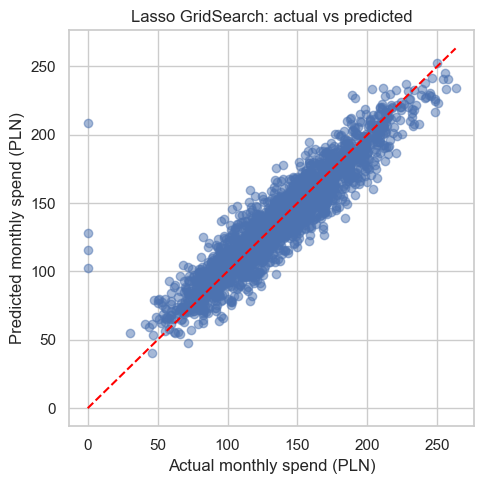

In [21]:
plt.figure(figsize=(5, 5))
plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="red"
)
plt.xlabel("Actual monthly spend (PLN)")
plt.ylabel("Predicted monthly spend (PLN)")
plt.title(f"{final_model_name}: actual vs predicted")
plt.tight_layout()
plt.show()

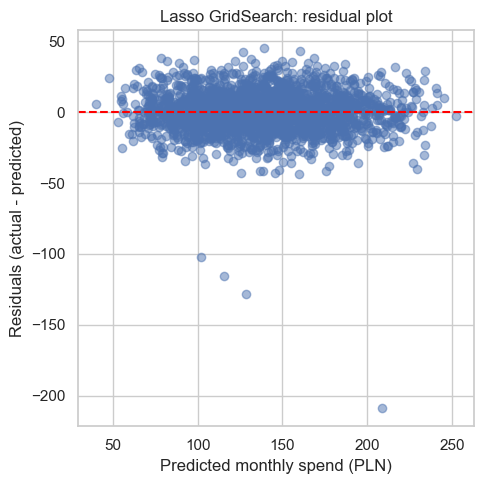

In [22]:
residuals = y_test - y_pred

plt.figure(figsize=(5, 5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted monthly spend (PLN)")
plt.ylabel("Residuals (actual - predicted)")
plt.title(f"{final_model_name}: residual plot")
plt.tight_layout()
plt.show()


# 16. Error analysis

The largest residuals in the test set all belong to a small group of four customers with an actual monthly spend of 0.00 PLN, for whom the model predicts between roughly 102 and 209 PLN. The next-largest error in the test set, for a customer with non-zero spend, is only about 45 PLN — a clear gap that sets this group apart from the rest.

These four customers do not share an obvious profile: they span three different subscription plans, tenure ranging from 8 to 39 months, satisfaction scores of 7–9 (at or above the dataset average), and 0–2 support tickets. Three of the four even have auto-renew enabled. None of the available features signals an unusually low likelihood of spending, so the model has no basis to anticipate a zero outcome for them — the cause most likely lies outside the current feature set (e.g. billing status or a mid-cycle pause not captured by `churned`).

Because RMSE penalizes large errors quadratically, this group has an outsized effect on that metric relative to its size — see the summary printed above. MAE is affected far less, which is part of why it was used as the primary model-selection metric. A natural next step, rather than expecting one regression to cover both regimes, would be a two-stage approach: first flag likely zero-spend customers, then model spend for the rest.

In [23]:
error_analysis = X_test.copy()

error_analysis["actual_spend"] = y_test
error_analysis["predicted_spend"] = y_pred
error_analysis["residual"] = y_test - y_pred
error_analysis["absolute_error"] = abs(y_test - y_pred)

error_analysis.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,age,city,plan,acquisition_channel,monthly_income_pln,tenure_months,avg_logins_last_30d,support_tickets_last_30d,satisfaction_score,auto_renew,discount_pct,actual_spend,predicted_spend,residual,absolute_error
3312,31.0,lublin,premium,social,5321.01,39,7,0,8.0,1,0,0.00,208.713883,-208.713883,208.713883
8437,25.0,lublin,standard,paid_search,7889.35,19,8,2,7.0,0,0,0.00,128.364952,-128.364952,128.364952
5012,44.0,poznań,standard,organic,8963.15,8,10,0,9.0,1,15,0.00,115.715458,-115.715458,115.715458
315,27.0,łódź,basic,paid_search,7006.72,15,7,1,8.0,1,0,0.00,102.264857,-102.264857,102.264857
8236,37.0,kraków,standard,referral,9891.39,15,12,0,9.0,1,10,183.99,139.031260,44.958740,44.958740
3577,28.0,kraków,premium,organic,10455.58,8,8,0,10.0,0,0,116.11,159.835657,-43.725657,43.725657
3133,35.0,warszawa,standard,partner,10002.10,26,8,0,7.0,1,0,203.73,160.492862,43.237138,43.237138
7937,18.0,lublin,standard,organic,3988.16,15,5,0,9.0,1,0,82.31,125.494624,-43.184624,43.184624
330,39.0,kraków,basic,referral,6962.77,29,12,0,10.0,1,0,102.84,145.895695,-43.055695,43.055695
9157,29.0,lublin,premium,social,4170.74,1,10,0,8.0,1,15,169.19,126.891396,42.298604,42.298604


In [24]:
zero_mask = error_analysis["actual_spend"] == 0
n_zero = zero_mask.sum()
share_of_sse = (error_analysis.loc[zero_mask, "residual"] ** 2).sum() / (error_analysis["residual"] ** 2).sum()

print(f"Zero-spend rows in test set: {n_zero} ({n_zero/len(error_analysis):.1%} of test rows)")
print(f"Share of total squared error: {share_of_sse:.1%}")

Zero-spend rows in test set: 4 (0.2% of test rows)
Share of total squared error: 17.7%


## 16.1 Error analysis by spending group

Error is broadly consistent across spending levels, at roughly 11–13 PLN MAE in every group. The mean error, however, is negative for low spenders and positive for high spenders: −8.11 PLN for customers spending ≤100 PLN and +8.24 PLN for customers spending 200+ PLN. This is expected regression-to-the-mean behaviour — any model with R² below 1 will pull predictions for low actual values upward and for high actual values downward, since it is minimizing average error rather than matching each value exactly. The four zero-spend customers discussed in section 16 explain only a small part of this: about 18% of the ≤100 PLN group's average error, with the remaining 82% coming from ordinary low-spending customers being modestly overestimated.

In [25]:
error_analysis["spend_group"] = pd.cut(
    error_analysis["actual_spend"],
    bins=[-np.inf, 100, 150, 200, np.inf],
    labels=[
        "<100",
        "100–150",
        "150–200",
        "> 200 ",
    ]
)

error_by_spend_group = (
    error_analysis
    .groupby(
        "spend_group",
        observed=True
    )
    .agg(
        n=("actual_spend", "size"),
        MAE=("absolute_error", "mean"),
        Mean_Error=("residual", "mean")
    )
    .reset_index()
)

error_by_spend_group

,spend_group,n,MAE,Mean_Error
0,<100,373,12.664789,-8.106519
1,100–150,805,11.055633,-0.558250
2,150–200,669,11.093538,3.865717
3,> 200,152,11.886757,8.239334


# 17. Feature importance

The Lasso model's coefficients show which features are most associated with predicted monthly spend. Because numeric features were standardized before fitting, their coefficients represent the effect of a one-standard-deviation change, while the one-hot encoded categorical features (plan, city) represent the effect of belonging to that category relative to the reference level — the two are not directly comparable on the same scale.

Subscription plan dominates the model: being on the premium plan is associated with roughly +36 PLN relative to the reference level, and the basic plan with roughly −28 PLN. `tenure_months` is the next largest effect, at about +24 PLN per standard deviation of tenure (~12 months). Every other feature — logins, satisfaction, income, auto-renew, discount, and the city dummies — contributes only a few PLN each; several of the smallest city coefficients fill out the rest of the "top 15" list.

As with any linear model, these coefficients describe associations learned from the training data and should not be interpreted as causal effects.

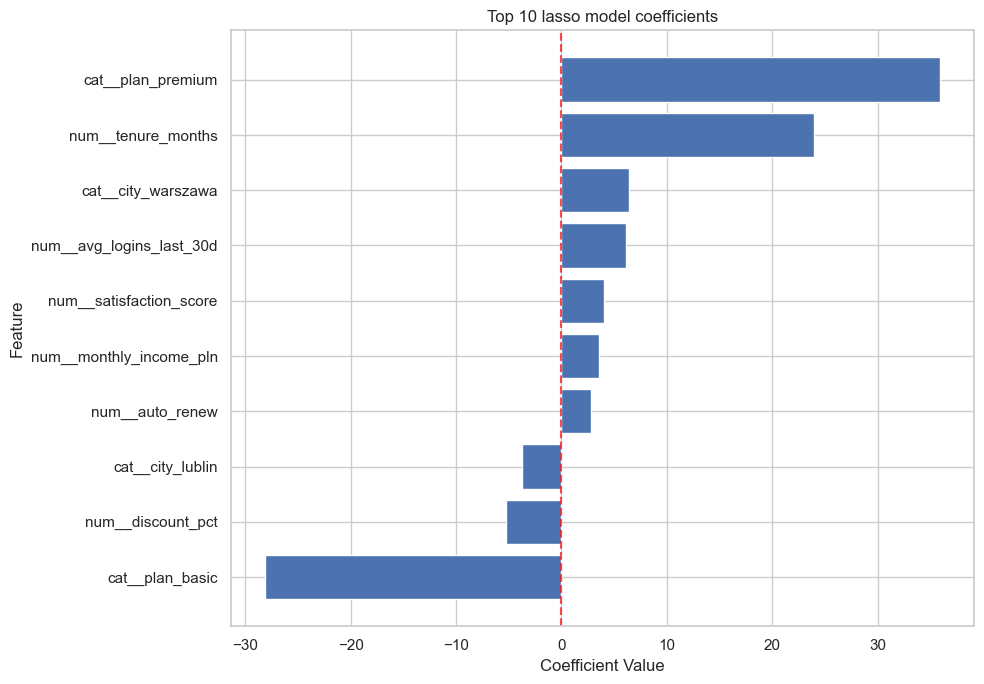

In [26]:
feature_names = final_model["preprocessor"].get_feature_names_out()
coefficients = final_model["regressor"].coef_

coef_df = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })
    .assign(abs_coefficient=lambda x: x["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .head(10) 
    .sort_values("coefficient", ascending=True) 
)

plt.figure(figsize=(10, 7))
plt.barh(coef_df["feature"], coef_df["coefficient"])
plt.axvline(0, color="red", linestyle="--", alpha=0.7)
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top 10 lasso model coefficients")
plt.tight_layout()
plt.show()

# 18. Conclusions

- Typical prediction error (test MAE) is about 11.4 PLN, roughly 8% of the average monthly spend of 139 PLN, consistent with the cross-validation estimate.
- Linear Regression, Ridge, and Lasso perform essentially the same; Lasso was selected as the final model for its simplicity and marginally lower CV MAE, not for a meaningful accuracy advantage. Tree-based models did not outperform the simple linear models on this dataset.
- Subscription plan is the strongest driver of predicted spend, followed by tenure; all other features play a minor role (section 17).
- A small group of customers with an actual spend of 0.00 PLN accounts for a disproportionate share of the model's error (section 16). Their profile is otherwise unremarkable, so this segment is not explained by the available features.
- The dataset was synthetically generated by an LLM with intentionally dirty data, so these findings describe patterns in the generator rather than real customer behavior.